In [7]:
import pandas as pd
import os
import numpy as np

labels = pd.read_csv("/home/cry_more/ongoing/TraceTheAce/data/train_labels.csv")
features = pd.read_csv("/home/cry_more/ongoing/TraceTheAce/data/train_features.csv")
train_transcript = os.listdir("/home/cry_more/ongoing/TraceTheAce/data/train_transcripts")

In [9]:
print("unique session id",len(features['session_id'].unique()))
print("unique response id",len(features['response_id'].unique()))
print("total session transcript",len(set(train_transcript)))

unique session id 22821
unique response id 35072
total session transcript 45642


# kfold

In [10]:
from sklearn.model_selection import StratifiedGroupKFold

train = pd.merge(features, labels, on="response_id")

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
train['fold'] = -1

for fold, (train_idx, val_idx) in enumerate(sgkf.split(train, y=train['is_correct'], groups=train['session_id'])):
    train.loc[val_idx, 'fold'] = fold

print(train.groupby('fold')['is_correct'].mean())

fold
0    0.702452
1    0.702452
2    0.702452
3    0.702495
4    0.702495
Name: is_correct, dtype: float64


In [11]:
train.to_csv("/home/cry_more/ongoing/TraceTheAce/data/train.csv",index=False)

In [6]:
train.describe()

,is_correct,fold
count,35072.000000,35072.000000
mean,0.702469,2.000086
std,0.457178,1.414244
min,0.000000,0.000000
25%,0.000000,1.000000
50%,1.000000,2.000000
75%,1.000000,3.000000
max,1.000000,4.000000


In [33]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 35072 entries, 0 to 35071
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   response_id            35072 non-null  str    
 1   session_id             35072 non-null  str    
 2   learning_objective_id  35072 non-null  str    
 3   learning_objective     35072 non-null  str    
 4   is_correct             35072 non-null  float64
 5   fold                   35072 non-null  int64  
dtypes: float64(1), int64(1), str(4)
memory usage: 1.6 MB


In [54]:
session_word = []
for session in train['session_id'].unique():
    filepath = os.path.join("/home/cry_more/ongoing/TraceTheAce/data/train_transcripts",f'{session}.csv')
    if os.path.exists(filepath):
        df = pd.read_csv(filepath)
        words = df['content'].fillna('').apply(lambda x: len(str(x).split())).sum()
        session_word.append(words)
        

In [56]:
session_word = pd.Series(session_word)

session_word.describe(percentiles=[0.5, 0.9, 0.95, 0.99])

count    22821.000000
mean      3590.347706
std        938.203169
min         39.000000
50%       3625.000000
90%       4752.000000
95%       5093.000000
99%       5745.000000
max       8512.000000
dtype: float64

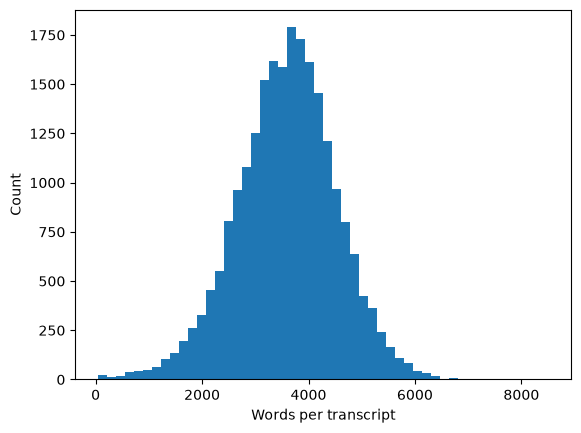

In [ ]:
import matplotlib.pyplot as plt

plt.hist(session_word, bins=50)
plt.xlabel("Words per transcript")
plt.ylabel("Count")
plt.show()